Практическое занятие №6 (Группа А)

Валидация и стандартизация алгоритма readiness_score

Шаг 1. Подготовка рабочей среды и загрузка данных

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print("Библиотеки успешно импортированы")

Библиотеки успешно импортированы


In [4]:
# 1.3. Загрузка витрины с readiness_score
readiness_df = pd.read_csv('company_readiness_for_pro.csv')
print(f"Количество записей в загруженном файле: {len(readiness_df)}")
print("\nПервые 5 строк:")
print(readiness_df.head())
print("\nСтатистика по колонке readiness_score:")
print(readiness_df['readiness_score'].describe())
print("\nСписок всех колонок:")
print(readiness_df.columns.tolist())

Количество записей в загруженном файле: 40

Первые 5 строк:
   company_id            company_name      industry region  employee_count  \
0        1001           ООО "Ромашка"        Retail    ЦФО             120   
1        1002        АО "ТехноСервис"            IT   СЗФО              45   
2        1003              ИП Сидоров      Services    ЮФО               5   
3        1004  ООО "Ромашка-Логистик"     Logistics    ЦФО              30   
4        1005       ЗАО "СтройИнвест"  Construction    ПФО             250   

     status  is_active_lms  login_count_90d  payment_stability  avg_check  \
0    active          1.000            1.000              1.000 175000.000   
1    active          1.000            1.000              1.000 335000.000   
2      lead          1.000            1.000              1.000  82500.000   
3    active          0.000            0.000              0.000      0.000   
4  inactive          1.000            1.000              1.000 500000.000   

   total

In [5]:
# 1.4. Загрузка исторических данных о выручке
history_df = pd.read_csv('12_company_history.csv')
print(f"Количество записей: {len(history_df)}")
print(f"Уникальные значения в колонке quarter: {history_df['quarter'].unique()}")
print("\nПервые 3 строки:")
print(history_df.head(3))

Количество записей: 200
Уникальные значения в колонке quarter: ['2024Q1' '2024Q2' '2024Q3' '2024Q4' '2025Q1']

Первые 3 строки:
   company_id quarter              segment  revenue_quarter
0        1001  2024Q1    Large_High_Active           450000
1        1001  2024Q2    Large_High_Active           380000
2        1001  2024Q3  Large_Medium_Active           120000


In [10]:
# 1.5. Извлечение порога отбора из файла пре-регистрации
pilot_threshold = 0.7594  # значение по умолчанию
try:
    with open('pre_registration_group_A.md', 'r', encoding='utf-8') as f:
        content = f.read()
    # Поиск порога в тексте
    match = re.search(r'readiness_score\s*[>=]+\s*([0-9.]+)', content)
    if match:
        pilot_threshold = float(match.group(1))
        print(f"Порог из файла: {pilot_threshold}")
    else:
        print(f"Порог не найден, используем значение по умолчанию: {pilot_threshold}")
except FileNotFoundError:
    print(f"Файл не найден, используем значение по умолчанию: {pilot_threshold}")


Порог из файла: 0.759


In [11]:
# 1.6. Проверка согласованности данных
print("\n1.6. Проверка согласованности данных...")
readiness_ids = set(readiness_df['company_id'])
history_ids = set(history_df['company_id'])
missing_ids = readiness_ids - history_ids
print(f"Компании из readiness_df: {len(readiness_ids)}")
print(f"Компании из history_df: {len(history_ids)}")
print(f"Компании, которые есть в readiness_df, но отсутствуют в history_df: {len(missing_ids)}")
if len(missing_ids) > 0:
    print(f"  Их ID: {list(missing_ids)}")


1.6. Проверка согласованности данных...
Компании из readiness_df: 40
Компании из history_df: 40
Компании, которые есть в readiness_df, но отсутствуют в history_df: 0


Шаг 2. Валидация стабильности во времени

In [13]:
# 2.1. Определение групп компаний для анализа
median_threshold = readiness_df['readiness_score'].median()
print(f"Медиана readiness_score: {median_threshold:.4f}")

# Группы по медиане
readiness_df['score_group_median'] = np.where(
    readiness_df['readiness_score'] >= median_threshold,
    'high_score', 'low_score'
)

# Группы по порогу из Пр-3
readiness_df['score_group_pilot'] = np.where(
    readiness_df['readiness_score'] >= pilot_threshold,
    'high_score', 'low_score'
)

print(f"\nГруппы по медиане:")
print(readiness_df['score_group_median'].value_counts())
print(f"\nГруппы по порогу из Пр-3 ({pilot_threshold}):")
print(readiness_df['score_group_pilot'].value_counts())

high_median_count = len(readiness_df[readiness_df['score_group_median'] == 'high_score'])
print(f"\nСколько компаний с score >= медианы попало в пилот: {high_median_count} (из топ-50%)")

Медиана readiness_score: 0.7282

Группы по медиане:
score_group_median
high_score    20
low_score     20
Name: count, dtype: int64

Группы по порогу из Пр-3 (0.759):
score_group_pilot
low_score     28
high_score    12
Name: count, dtype: int64

Сколько компаний с score >= медианы попало в пилот: 20 (из топ-50%)


In [15]:
# 2.2. Подготовка исторических данных для анализа
history_analysis = history_df.copy()

# Получаем списки ID для каждой группы
high_median_ids = readiness_df[readiness_df['score_group_median'] == 'high_score']['company_id'].tolist()
low_median_ids = readiness_df[readiness_df['score_group_median'] == 'low_score']['company_id'].tolist()
high_pilot_ids = readiness_df[readiness_df['score_group_pilot'] == 'high_score']['company_id'].tolist()
low_pilot_ids = readiness_df[readiness_df['score_group_pilot'] == 'low_score']['company_id'].tolist()

# Добавляем колонки групп
history_analysis['group_median'] = 'unknown'
history_analysis.loc[history_analysis['company_id'].isin(high_median_ids), 'group_median'] = 'high_score'
history_analysis.loc[history_analysis['company_id'].isin(low_median_ids), 'group_median'] = 'low_score'

history_analysis['group_pilot'] = 'unknown'
history_analysis.loc[history_analysis['company_id'].isin(high_pilot_ids), 'group_pilot'] = 'high_score'
history_analysis.loc[history_analysis['company_id'].isin(low_pilot_ids), 'group_pilot'] = 'low_score'

# Удаляем строки с неизвестной группой
history_analysis = history_analysis[history_analysis['group_median'] != 'unknown']
print(f"Исторических записей для анализа (после фильтрации): {len(history_analysis)}")

Исторических записей для анализа (после фильтрации): 200


In [17]:
# 2.3. Расчет средней выручки по кварталам для групп (по медиане)
quarterly_median = history_analysis.groupby(['quarter', 'group_median'])['revenue_quarter'].mean().unstack()
print(quarterly_median)

group_median  high_score  low_score
quarter                            
2024Q1        239150.000 174850.000
2024Q2        243550.000 175700.000
2024Q3        212650.000 177750.000
2024Q4        221100.000 203450.000
2025Q1        248400.000 194150.000


In [18]:
# 2.4. Расчет средней выручки по кварталам для групп (по порогу из Пр-3)
quarterly_pilot = history_analysis.groupby(['quarter', 'group_pilot'])['revenue_quarter'].mean().unstack()
print(quarterly_pilot)

group_pilot  high_score  low_score
quarter                           
2024Q1       323750.000 156964.286
2024Q2       325833.333 159821.429
2024Q3       293333.333 153142.857
2024Q4       295000.000 176821.429
2025Q1       312500.000 182178.571


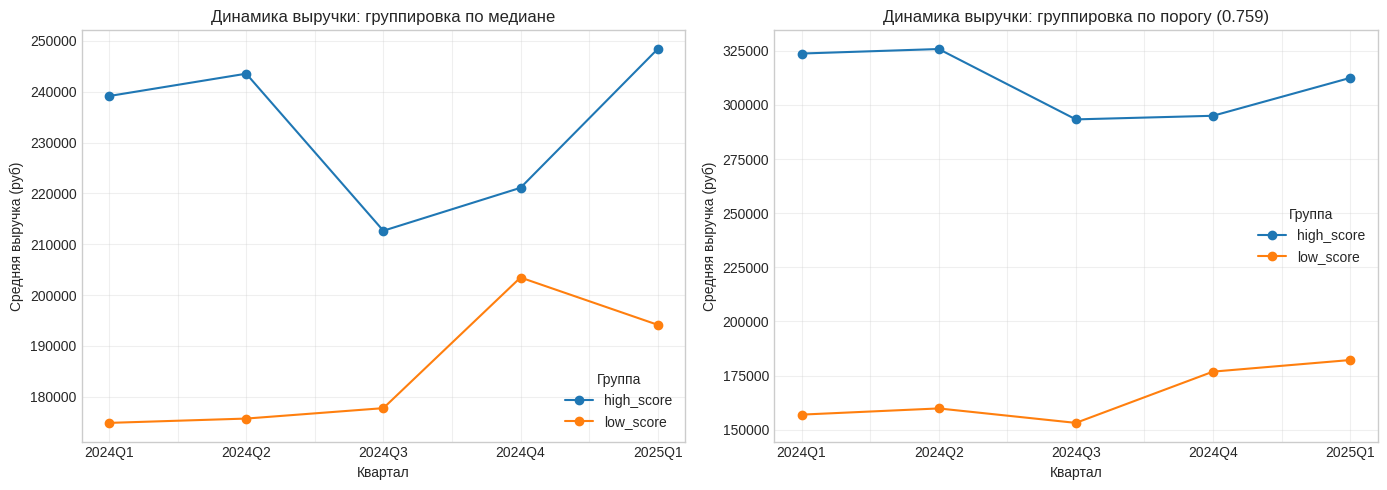

In [19]:
# 2.5. Визуализация динамики выручки для обоих подходов
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# График по медиане
quarterly_median.plot(ax=ax1, marker='o')
ax1.set_title('Динамика выручки: группировка по медиане')
ax1.set_xlabel('Квартал')
ax1.set_ylabel('Средняя выручка (руб)')
ax1.legend(title='Группа')
ax1.grid(True, alpha=0.3)

# График по порогу
quarterly_pilot.plot(ax=ax2, marker='o')
ax2.set_title(f'Динамика выручки: группировка по порогу ({pilot_threshold})')
ax2.set_xlabel('Квартал')
ax2.set_ylabel('Средняя выручка (руб)')
ax2.legend(title='Группа')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# 2.6. Статистическая проверка различий (по медиане)
results_median = []
for quarter in quarterly_median.index:
    high_vals = history_analysis[(history_analysis['quarter'] == quarter) &
                                  (history_analysis['group_median'] == 'high_score')]['revenue_quarter']
    low_vals = history_analysis[(history_analysis['quarter'] == quarter) &
                                 (history_analysis['group_median'] == 'low_score')]['revenue_quarter']
    if len(high_vals) > 1 and len(low_vals) > 1:
        t_stat, p_value = stats.ttest_ind(high_vals, low_vals, equal_var=False)
        results_median.append({'quarter': quarter, 'p_value': p_value, 'significant': p_value < 0.05})
        print(f"{quarter}: p-value = {p_value:.4f} (значимо: {p_value < 0.05})")

results_median_df = pd.DataFrame(results_median)
print("\nРезультаты t-теста:")
print(results_median_df)

2024Q1: p-value = 0.3409 (значимо: False)
2024Q2: p-value = 0.3051 (значимо: False)
2024Q3: p-value = 0.6023 (значимо: False)
2024Q4: p-value = 0.8018 (значимо: False)
2025Q1: p-value = 0.3266 (значимо: False)

Результаты t-теста:
  quarter  p_value  significant
0  2024Q1    0.341        False
1  2024Q2    0.305        False
2  2024Q3    0.602        False
3  2024Q4    0.802        False
4  2025Q1    0.327        False


Шаг 3. Валидация логики на пограничных случаях

In [24]:
# 3.1. Поиск компаний с нулевой активностью в LMS
inactive = readiness_df[readiness_df['is_active_lms'] == 0]
print(f"Количество таких компаний: {len(inactive)}")
print(f"Максимальный readiness_score среди них: {inactive['readiness_score'].max():.4f}")
print("\nПримеры:")
print(inactive[['company_id', 'company_name', 'readiness_score', 'payment_stability', 'norm_avg_check']].head())

Количество таких компаний: 16
Максимальный readiness_score среди них: 0.6100

Примеры:
    company_id            company_name  readiness_score  payment_stability  \
3         1004  ООО "Ромашка-Логистик"            0.000              0.000   
7         1008    ООО "Бизнес-Консалт"            0.000              0.000   
8         1009        АО "ФинансГрупп"            0.610              1.000   
9         1010           ООО "ПромТех"            0.439              1.000   
11        1012         АО "ЭнергоСбыт"            0.000              0.000   

    norm_avg_check  
3            0.000  
7            0.000  
8            0.700  
9            0.130  
11           0.000  


In [25]:
# 3.2. Поиск компаний с нулевой стабильностью платежей
unstable = readiness_df[readiness_df['payment_stability'] == 0]
print(f"Количество таких компаний: {len(unstable)}")
print(f"Максимальный readiness_score среди них: {unstable['readiness_score'].max():.4f}")
print("\nПримеры:")
print(unstable[['company_id', 'company_name', 'readiness_score', 'is_active_lms', 'norm_avg_check']].head())

Количество таких компаний: 9
Максимальный readiness_score среди них: 0.3000

Примеры:
    company_id            company_name  readiness_score  is_active_lms  \
3         1004  ООО "Ромашка-Логистик"            0.000          0.000   
7         1008    ООО "Бизнес-Консалт"            0.000          0.000   
11        1012         АО "ЭнергоСбыт"            0.000          0.000   
13        1014              ИП Петрова            0.000          0.000   
14        1015             ООО "Трейд"            0.000          0.000   

    norm_avg_check  
3            0.000  
7            0.000  
11           0.000  
13           0.000  
14           0.000  


In [29]:
# 3.3. Поиск компаний с максимальным чеком
max_check = readiness_df['norm_avg_check'].max()
high_check = readiness_df[readiness_df['norm_avg_check'] == max_check]
print(f"Компания(и) с максимальным нормированным чеком (1.0):")
print(high_check[['company_id', 'company_name', 'readiness_score', 'is_active_lms', 'payment_stability', 'avg_check']])

Компания(и) с максимальным нормированным чеком (1.0):
   company_id       company_name  readiness_score  is_active_lms  \
4        1005  ЗАО "СтройИнвест"            1.000          1.000   

   payment_stability  avg_check  
4              1.000 500000.000  


Шаг 4. Сравнение с простой альтернативой (Benchmarking)

In [31]:
# 4.1. Создание простого бенчмарка
readiness_df['simple_readiness'] = (readiness_df['payment_stability'] > 0.8).astype(int)
simple_pct = readiness_df['simple_readiness'].mean() * 100
print(f"Доля компаний, отобранных простым методом: {simple_pct:.1f}%")

Доля компаний, отобранных простым методом: 75.0%


In [32]:
# 4.2. Определение пересечений и различий
complex_selected = set(readiness_df[readiness_df['score_group_median'] == 'high_score']['company_id'])
simple_selected = set(readiness_df[readiness_df['simple_readiness'] == 1]['company_id'])

intersection = complex_selected.intersection(simple_selected)
only_complex = complex_selected.difference(simple_selected)
only_simple = simple_selected.difference(complex_selected)

print(f"Сложный метод (медиана): {len(complex_selected)} компаний")
print(f"Простой метод (payment_stability > 0.8): {len(simple_selected)} компаний")
print(f"Пересечение: {len(intersection)}")
print(f"Только сложный метод: {len(only_complex)}")
print(f"Только простой метод: {len(only_simple)}")

Сложный метод (медиана): 20 компаний
Простой метод (payment_stability > 0.8): 30 компаний
Пересечение: 20
Только сложный метод: 0
Только простой метод: 10


In [35]:
# 4.3. Анализ профиля компаний из группы "только сложный метод"
only_complex_profile = readiness_df[readiness_df['company_id'].isin(only_complex)]
if len(only_complex_profile) > 0:
    print(f"Количество: {len(only_complex_profile)}")
    print(f"Активность в LMS: {only_complex_profile['is_active_lms'].mean():.1%}")
    print(f"Стабильность платежей: {only_complex_profile['payment_stability'].mean():.2f}")
    print(f"Нормированный чек: {only_complex_profile['norm_avg_check'].mean():.3f}")
    print("\nПримеры:")
    print(only_complex_profile[['company_id', 'company_name', 'is_active_lms', 'payment_stability', 'norm_avg_check', 'readiness_score']].head())

In [36]:
# 4.4. Анализ профиля компаний из группы "только простой метод"
only_simple_profile = readiness_df[readiness_df['company_id'].isin(only_simple)]
if len(only_simple_profile) > 0:
    print(f"Количество: {len(only_simple_profile)}")
    print(f"Активность в LMS: {only_simple_profile['is_active_lms'].mean():.1%}")
    print(f"Стабильность платежей: {only_simple_profile['payment_stability'].mean():.2f}")
    print(f"Нормированный чек: {only_simple_profile['norm_avg_check'].mean():.3f}")
    print("\nПримеры:")
    print(only_simple_profile[['company_id', 'company_name', 'is_active_lms', 'payment_stability', 'norm_avg_check', 'readiness_score']].head())

Количество: 10
Активность в LMS: 20.0%
Стабильность платежей: 1.00
Нормированный чек: 0.272

Примеры:
    company_id          company_name  is_active_lms  payment_stability  \
5         1006    ООО "Айти-Решения"          1.000              1.000   
8         1009      АО "ФинансГрупп"          0.000              1.000   
9         1010         ООО "ПромТех"          0.000              1.000   
25        1026             ИП Козлов          1.000              1.000   
31        1032  ООО "Торговый Дом-2"          0.000              1.000   

    norm_avg_check  readiness_score  
5            0.060            0.718  
8            0.700            0.610  
9            0.130            0.439  
25           0.088            0.726  
31           0.100            0.430  
